The plan here is to:

* Create a county-CD level record of 2024 results as a baseline. 
* We will not use a regional swing model, as it is largely unecessary due to smaller nature of the elections. Instead, we will use the range-based model with the counties as units.
* Swing arrows need to also be drawn on marimekko.
* Fix marimekko axis labels.
* Marimekko bars semi-transparent when not fully reported.

In [1]:
import pandas as pd
import numpy as np

import utils

# Contains some code that needs to be used by other notebooks.
import sos

# 2024 election data for now
df = pd.read_json('./export-2024NovGen.json', typ='series')
df = sos.prepare_export_df(df, use_advanced=True)

lr = df['localResults'].set_index('name')

lr['ballotItems'] = lr['ballotItems'].map(lambda bi: bi[bi['name'].apply(lambda n: 'US House of Representatives' in n)])

districts = {}

for county in lr.index.unique():
    bis = lr.loc[county, 'ballotItems']
    propr_county_name = county.replace(' County', '')
    bis = bis.set_index('name')
    for district in bis.index.unique():
        bi = bis.loc[district]
        bos = pd.DataFrame.from_records(bi['ballotOptions'], index='name')
        rs = [pd.DataFrame.from_records(gr)['reportingStatus'] for gr in bos['precinctResults'].values[0]]
        bi['FR/ENC'] = np.all([r.isin(['Fully Reported', 'Election Night Complete']) for r in rs])
        bi['ballotOptions'] = bos
        if district not in districts:
            districts[district] = pd.DataFrame([bi], index=[propr_county_name])

        else:
            districts[district].loc[propr_county_name] = bi

        for candidate in bos.index:
            districts[district].loc[propr_county_name, candidate] = bos.loc[candidate,'voteCount']

districts['US House of Representatives - District 1']

,type,id,voteFor,ballotOrder,precinctsParticipating,precinctsReporting,contestType,ballotOptions,rankedChoiceResults,FR/ENC,"Earl L. ""Buddy"" Carter (I) (Rep)",Patti Hewitt (Dem)
Pierce,Local,30100,1,2,8,8,Candidate,id ballotOrd...,None,True,8626.0,891.0
McIntosh,Local,30100,1,2,5,5,Candidate,id ballotOrd...,None,True,4939.0,2245.0
Liberty,Local,30100,1,2,12,12,Candidate,id ballotOrd...,None,True,10531.0,11926.0
Ware,Local,30100,1,2,13,13,Candidate,id ballotOrd...,None,True,10437.0,3509.0
Bacon,Local,30100,1,2,1,1,Candidate,id ballotOrd...,None,True,4157.0,505.0
Glynn,Local,30100,1,2,17,17,Candidate,id ballotOrd...,None,True,28776.0,14141.0
Camden,Local,30100,1,2,11,11,Candidate,id ballotOrd...,None,True,18110.0,7637.0
Chatham,Local,30100,1,2,87,87,Candidate,id ballotOrd...,None,True,64221.0,74538.0
Wayne,Local,30100,1,2,12,12,Candidate,id ballotOrd...,None,True,11003.0,2288.0
Bryan,Local,30100,1,2,10,10,Candidate,id ballotOrd...,None,True,17404.0,6815.0


In [2]:
import geopandas
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Arrow, Rectangle

counties = geopandas.read_file('./gis/cong_w_counties.zip')

strong_party_colors = {
    'Rep': 'crimson',
    'Dem': 'royalblue',
    'Lib': 'orange'
}

light_party_colors = {
    'Rep': 'salmon',
    'Dem': 'cadetblue',
    'Lib': 'orange'
}

def color_for_cand(color_map: dict, cand):
    for party, color in color_map.items():
        if f'({party})' in cand:
            return color

    return 'gray'

def cd_map(dist_num: int):
    district_fp = f'{dist_num:0>2}'
    race = f'US House of Representatives - District {dist_num}'
    df = districts[race]
    district_counties = counties[counties['CD119FP'] == district_fp].set_index('NAME')

    candidates = df['ballotOptions'].tolist()[0].index

    district_counties: geopandas.GeoDataFrame = district_counties.loc[df.index]
    district_counties = district_counties[['geometry']].join(df)
    def winner(i):
        votes = district_counties.loc[i, candidates]
        maxvotes = votes.max()
        if votes.value_counts()[maxvotes] > 1:
            return 'Tie'
        else:
            c = votes.index
            return c[votes.argmax()]
    district_counties['Leader'] = district_counties.index.map(winner)

    # Colors

    strong_candidate_colors = {
        cand: color_for_cand(strong_party_colors, cand)
        for cand in candidates
    }

    light_candidate_colors = {
        cand: color_for_cand(light_party_colors, cand)
        for cand in candidates
    }

    cmap_strong = mcolors.ListedColormap([strong_candidate_colors[s] for s in district_counties['Leader'].unique()])
    cmap_light = mcolors.ListedColormap([light_candidate_colors[s] for s in candidates])

    # Plot map

    district_counties['alpha'] = district_counties['FR/ENC'].rename({'True': 1, 'False': 0.5})
    fig, axes = plt.subplots(1, 2, figsize=(16,9), squeeze=True)
    ax = axes[0]
    ax = district_counties.plot(column='Leader', legend=False, cmap=cmap_strong, ax=ax, 
                                edgecolor='white', linewidth=0.2, alpha=district_counties['alpha'])

    counties[counties['CD119FP'] != district_fp].dissolve().plot(autolim=False, ax=ax, color='gray')

    x_coord_counties = district_counties.centroid.x
    y_coord_counties = district_counties.centroid.y

    # Pies
    max_pie_r = 0.075
    district_counties['Total Votes'] = district_counties.apply(lambda x: x[candidates].sum(), axis=1)
    district_counties['p'] = district_counties['Total Votes'] / district_counties['Total Votes'].sum()
    district_counties['r'] = np.sqrt(district_counties['p'] / np.pi)
    benchmark = district_counties['r'].values.max()
    district_counties['r'] = district_counties['r'] / benchmark * max_pie_r

    district_counties['Prev. Balance'] = 0.5
    district_counties['Theta'] = np.radians(district_counties['Prev. Balance'] * 360 + 90)
    district_counties['Arrow dx'] = np.cos(district_counties['Theta']) * district_counties['r']
    district_counties['Arrow dy'] = np.sin(district_counties['Theta']) * district_counties['r']

    for county in district_counties.index.tolist():
        dc = district_counties.loc[county]
        text_y = y_coord_counties[county] + 0.025
        pie_y = y_coord_counties[county] - dc['r']

        dc[candidates].plot.pie(ax=ax, center=(x_coord_counties[county], pie_y),
                    radius=dc['r'], labels=None, cmap=cmap_light, startangle=90, frame=True, 
                    wedgeprops=dict(linewidth=0.5, edgecolor='w'))

        arr = Arrow(x=x_coord_counties[county], y=pie_y, 
                    dx=dc['Arrow dx'], 
                    dy=dc['Arrow dy'], 
                    width=0.025, color='black', linewidth=0)
        ax.add_patch(arr)
        
        ax.text(x=x_coord_counties[county], y=text_y, s=county, 
                horizontalalignment='center', verticalalignment='center',
                fontsize='small')

    ax.set_axis_off()
    ax.set_title(race)
    return district_counties[candidates], axes[1]

def cd_marimekko(data0: geopandas.GeoDataFrame, ax: plt.Axes):
    # Args
    data0 = data0[data0.sum().sort_values(ascending=False).index] # Sort by votes
    data = data0.to_numpy()
    normalize_x = True
    normalize_y = True
    bottom_n = 1
    sort = 'Prop'
    colors = [color_for_cand(strong_party_colors, cand) for cand in data0.columns]
    labels = data0.index

    def sort_key(x: tuple[np.ndarray]):
        (col, label) = x
        match sort:
            case 'Prop':
                return col[:bottom_n].sum() / col.sum()
            case 'Num':
                return col[:bottom_n].sum()
            case _:
                return 0
    data_sorted = sorted(zip(data, labels), key=sort_key, reverse=True)
    data = np.array([col for col, label in data_sorted])
    labels = np.array([label for col, label in data_sorted])
    widths = np.array([col.sum() for col in data])

    if normalize_y:
        data = np.array([col / col.sum() for col in data])

    max_y = np.array([col.sum() for col in data]).max()

    # Entrypoint

    xe = 0
    for col, width, label in zip(data, widths, labels):
        if normalize_x:
            width = width / widths.sum()

        bottom = col[:bottom_n]
        other = col[bottom_n:]
        ye = 0
        for height, color in zip(bottom, colors):
            rec = Rectangle((xe, ye), width=width, height=height, edgecolor='white', facecolor=color)
            ax.add_patch(rec)
            ye += height
        ye = max_y 
        for height, color in zip(other, colors[bottom_n:]):
                rec = Rectangle((xe, ye - height), width=width, height=height, edgecolor='white', facecolor=color)
                ax.add_patch(rec)
                ye -= height

        t = ax.text(x=xe, y=0, s=label)
        text_bb = t.get_tightbbox()
        corners = ax.transData.inverted().transform([(text_bb.x0, text_bb.y0), (text_bb.x1, text_bb.y1)])
        if corners[1, 0] - corners[0, 0] > width:
            t.remove()

        xe += width

    ax.set_xlim(0, xe)
    ax.set_ylim(0, max_y)
    ax.set_aspect('equal')
    plt.show()

# District 1

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


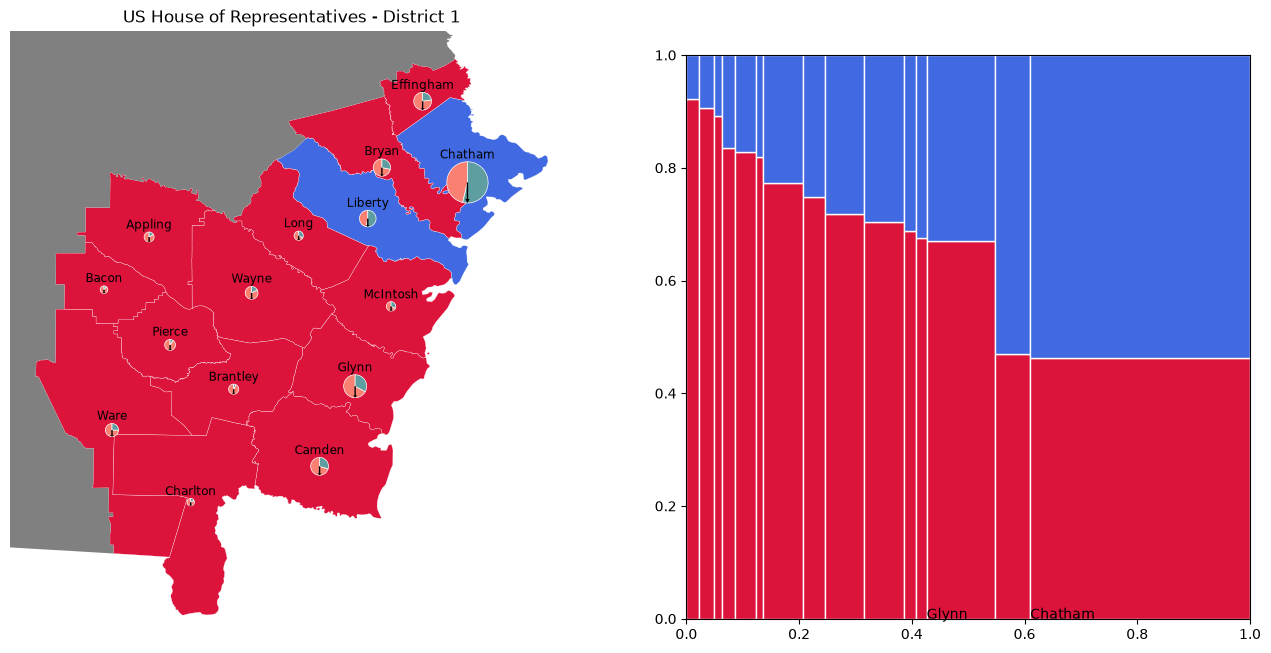

In [3]:
data0, ax = cd_map(1)
cd_marimekko(data0, ax)
plt.show()

# District 2

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


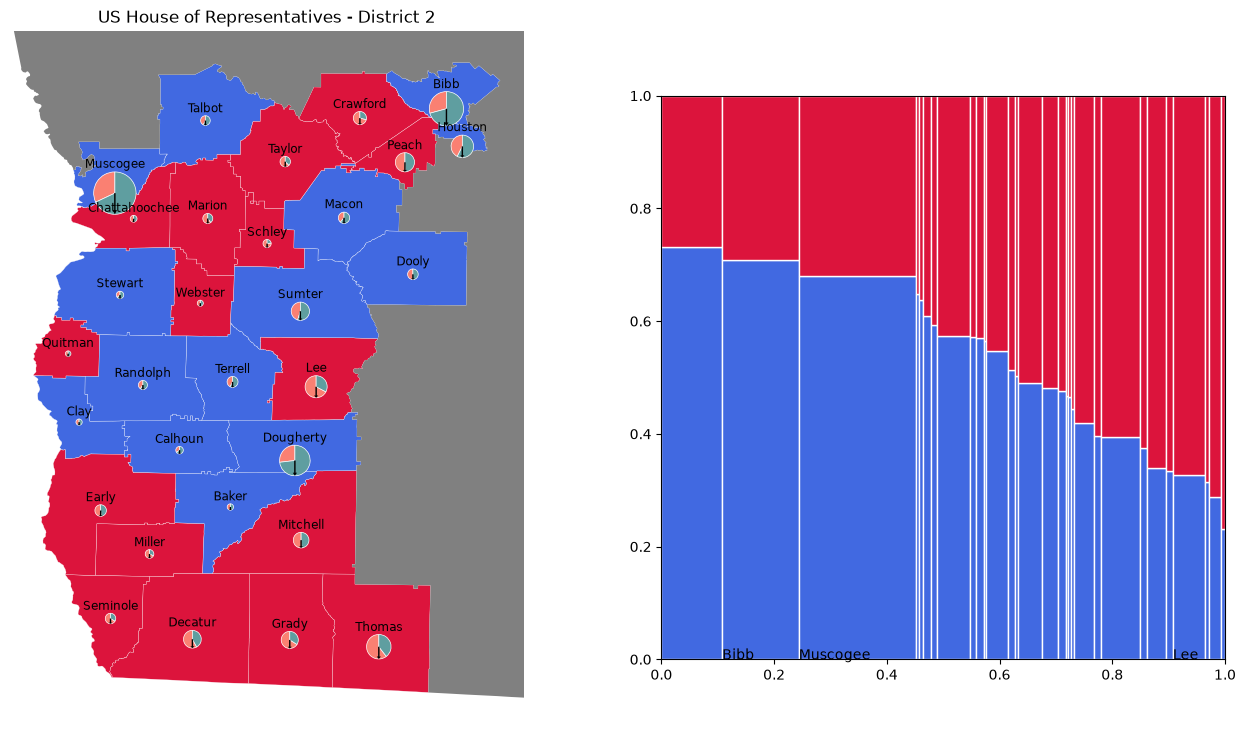

In [4]:
data0, ax = cd_map(2)
cd_marimekko(data0, ax)
plt.show()

# District 3

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


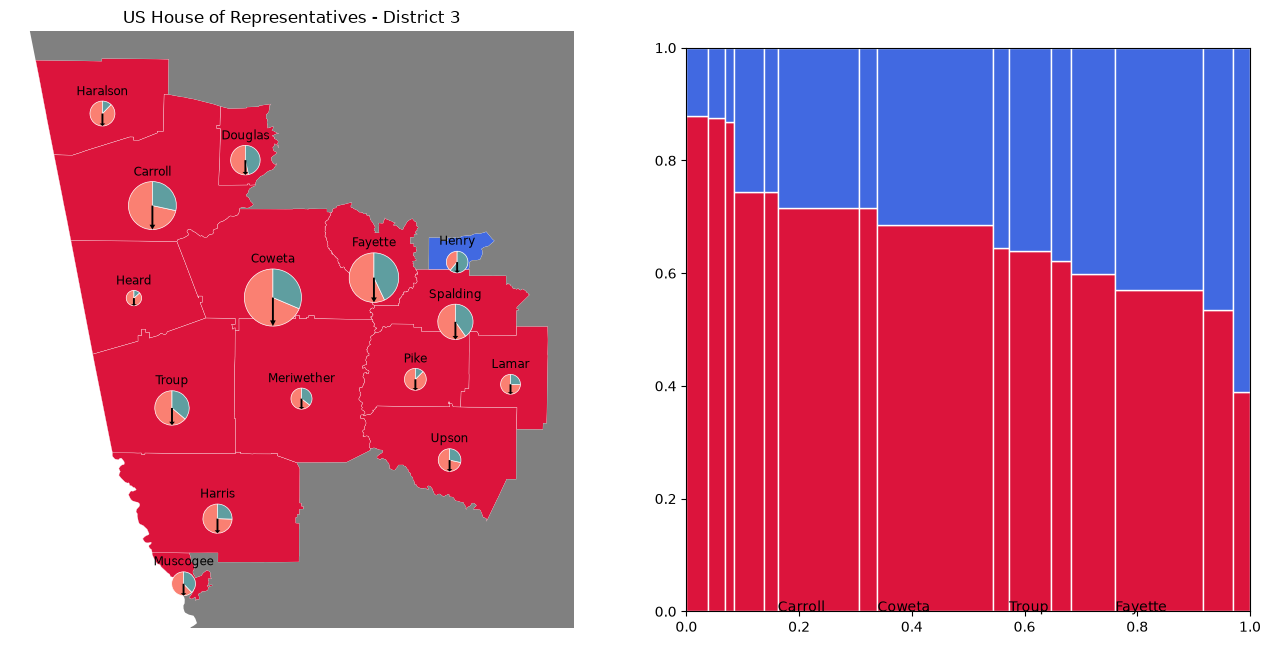

In [5]:
data0, ax = cd_map(3)
cd_marimekko(data0, ax)
plt.show()

# District 4

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


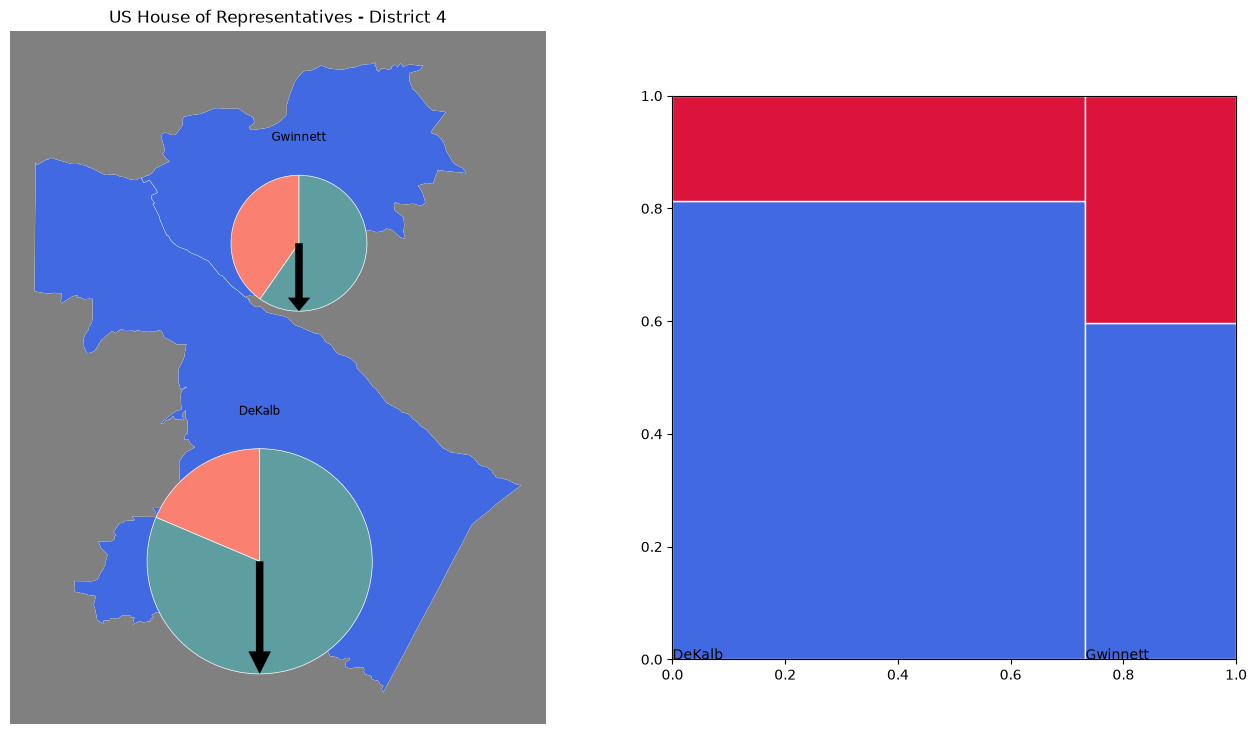

In [6]:
data0, ax = cd_map(4)
cd_marimekko(data0, ax)
plt.show()

# District 5

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


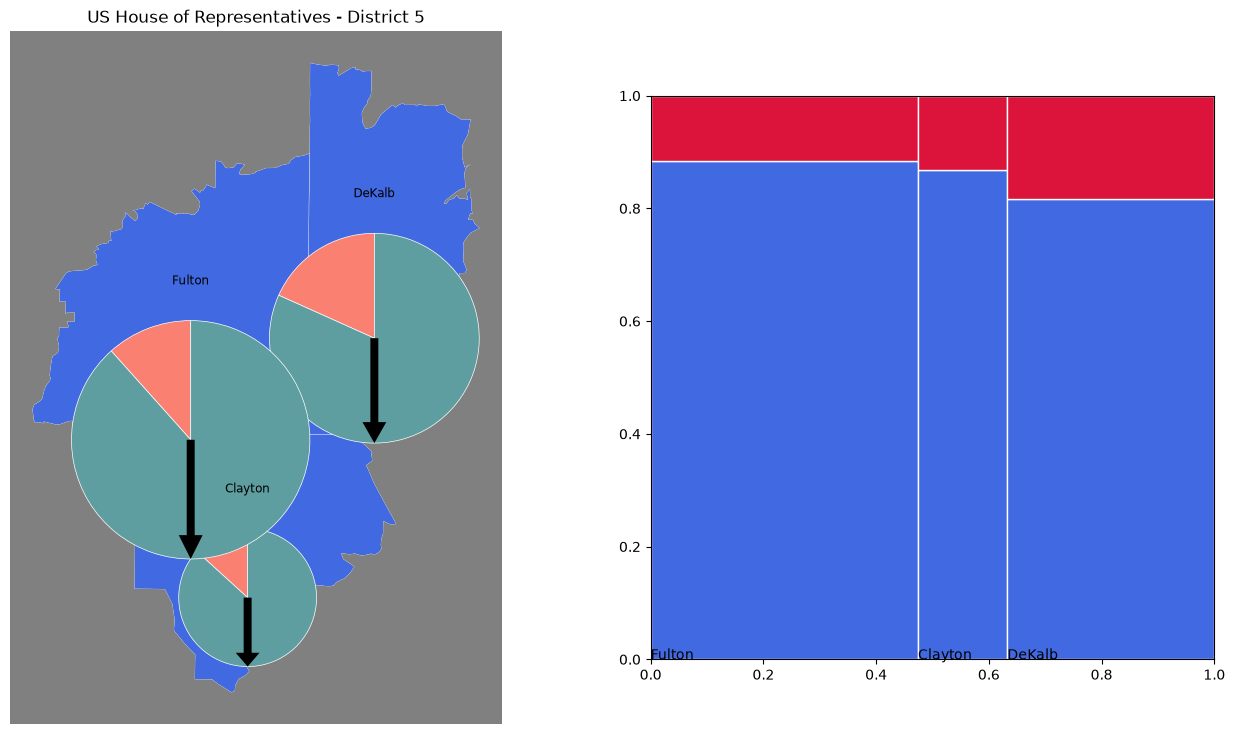

In [7]:
data0, ax = cd_map(5)
cd_marimekko(data0, ax)
plt.show()

# District 6

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


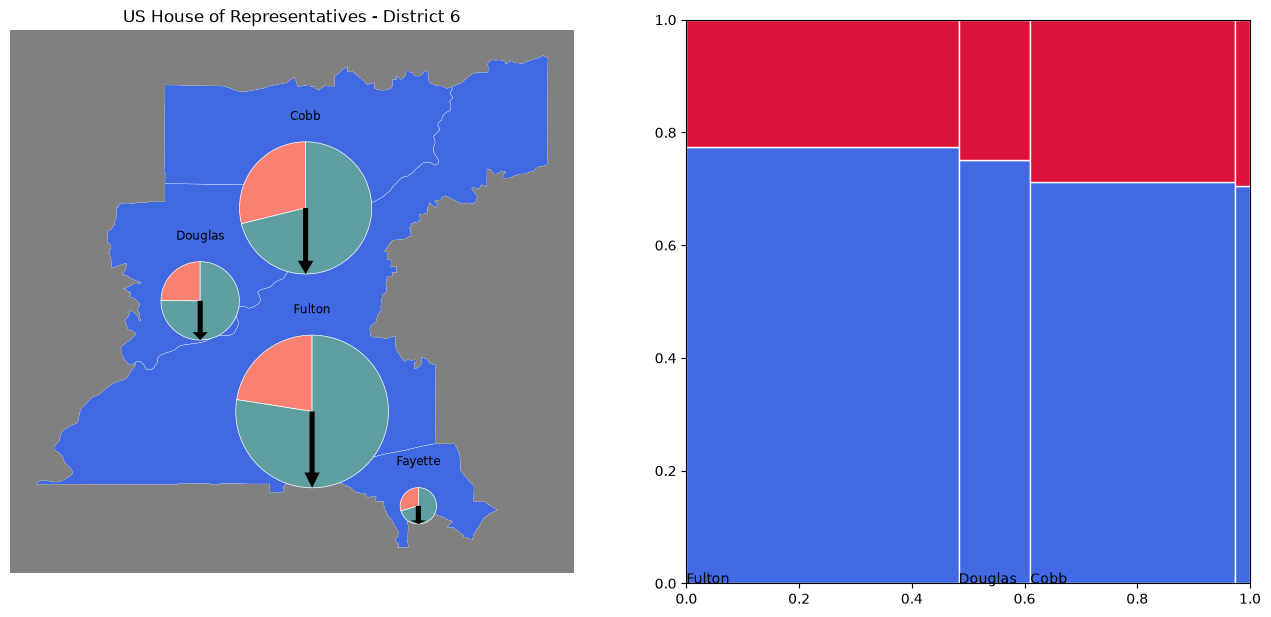

In [8]:
data0, ax = cd_map(6)
cd_marimekko(data0, ax)
plt.show()

# District 7

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


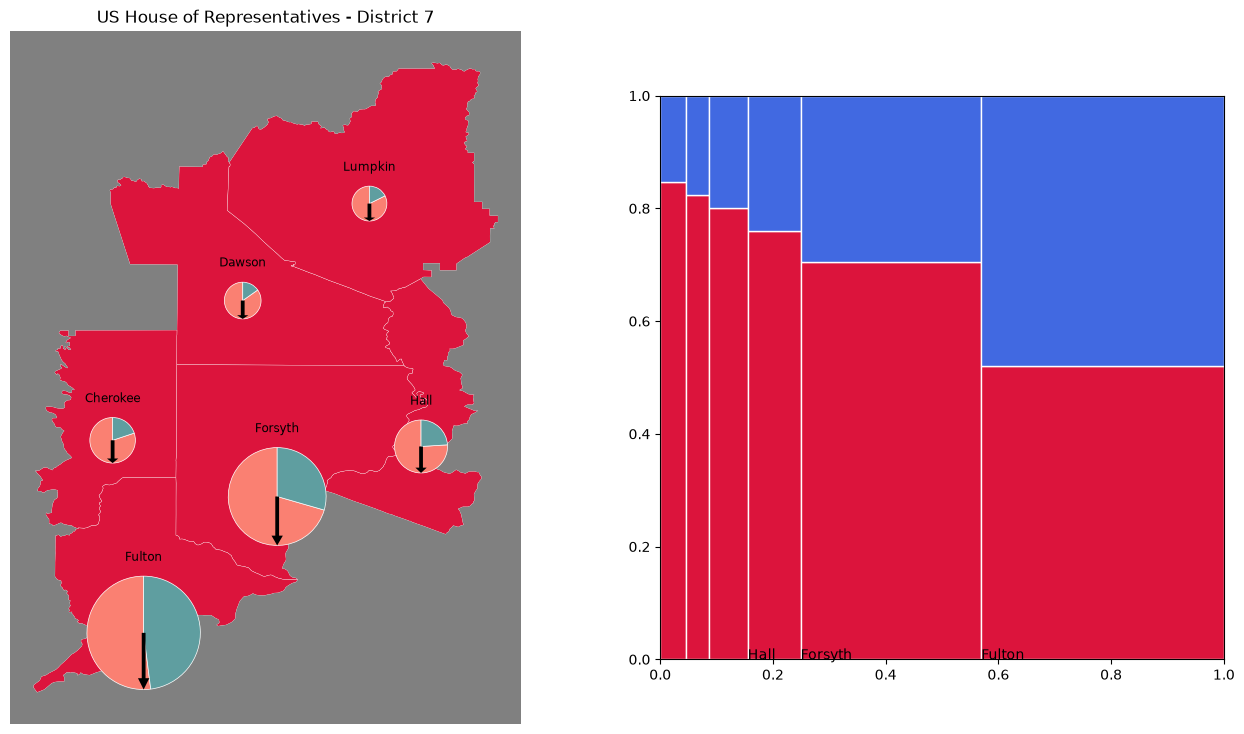

In [9]:
data0, ax = cd_map(7)
cd_marimekko(data0, ax)
plt.show()

# District 8

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


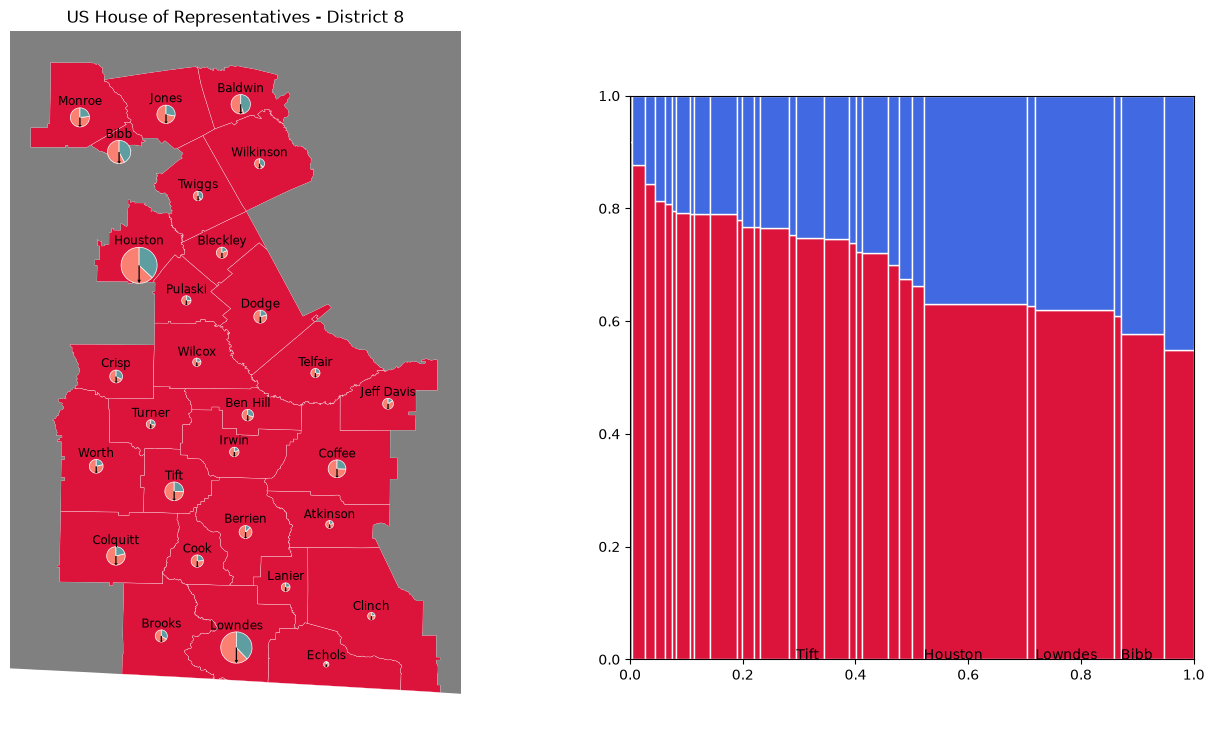

In [10]:
data0, ax = cd_map(8)
cd_marimekko(data0, ax)
plt.show()

# District 9

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


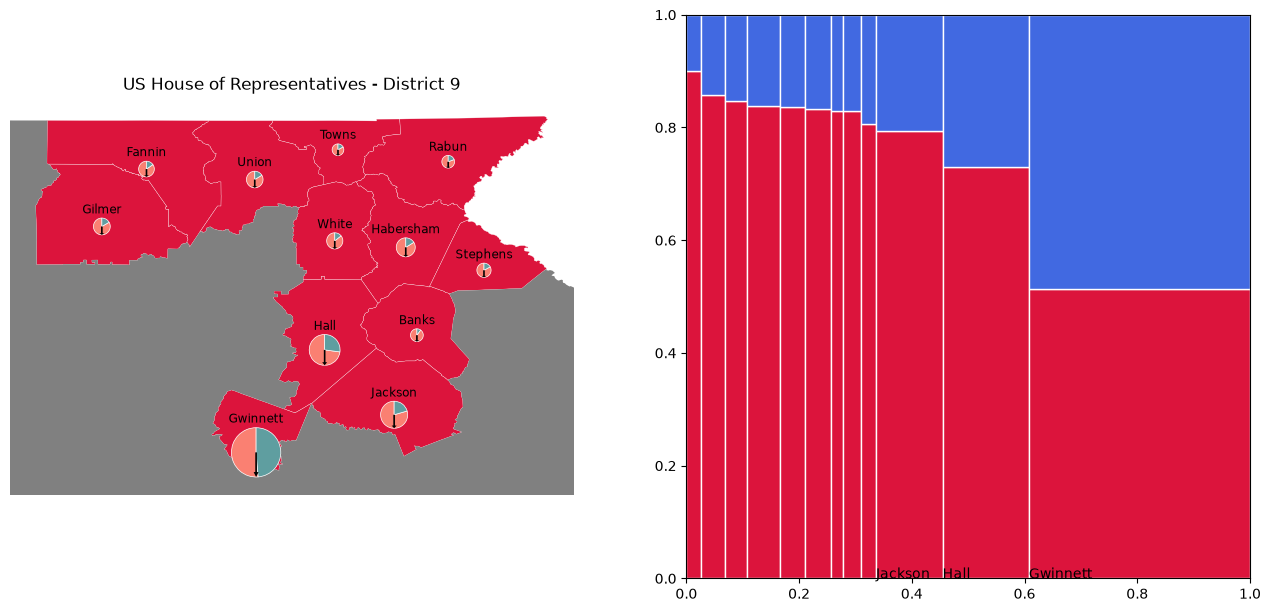

In [11]:
data0, ax = cd_map(9)
cd_marimekko(data0, ax)
plt.show()

# District 10

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


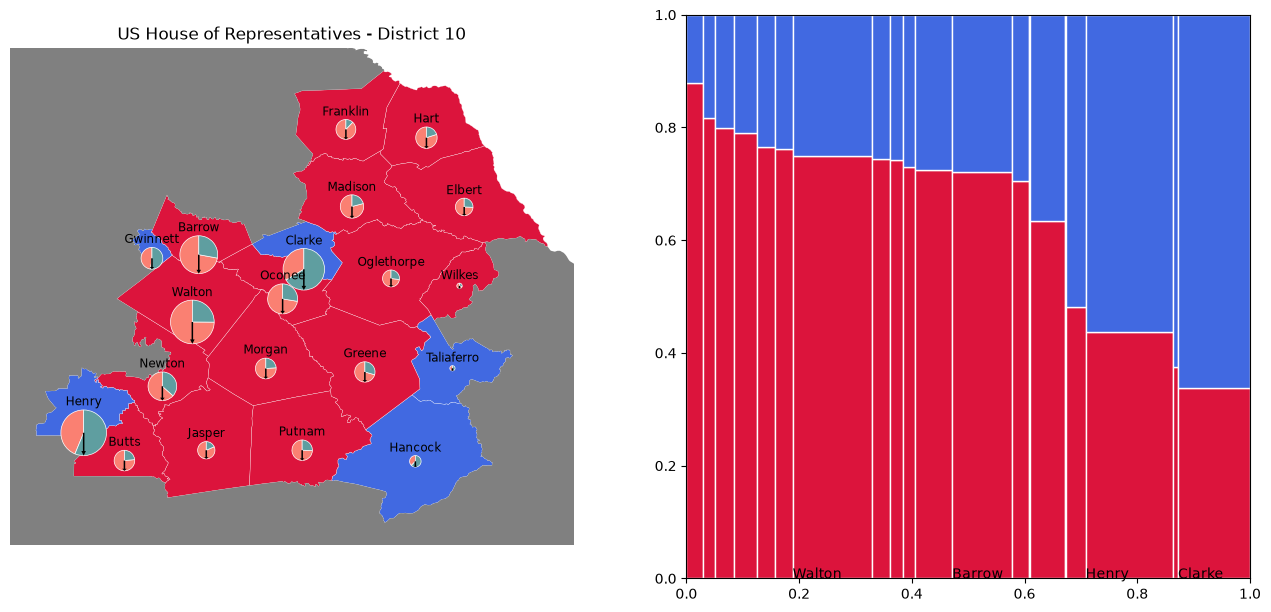

In [12]:
data0, ax = cd_map(10)
cd_marimekko(data0, ax)
plt.show()

# District 11

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


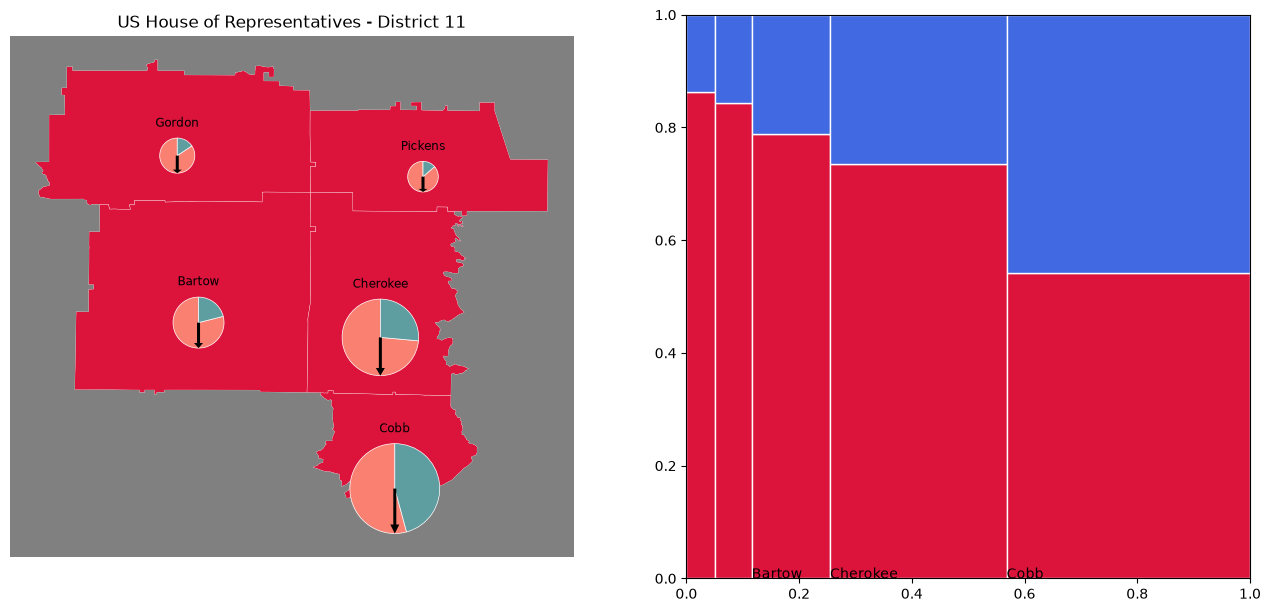

In [13]:
data0, ax = cd_map(11)
cd_marimekko(data0, ax)
plt.show()

# District 12

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


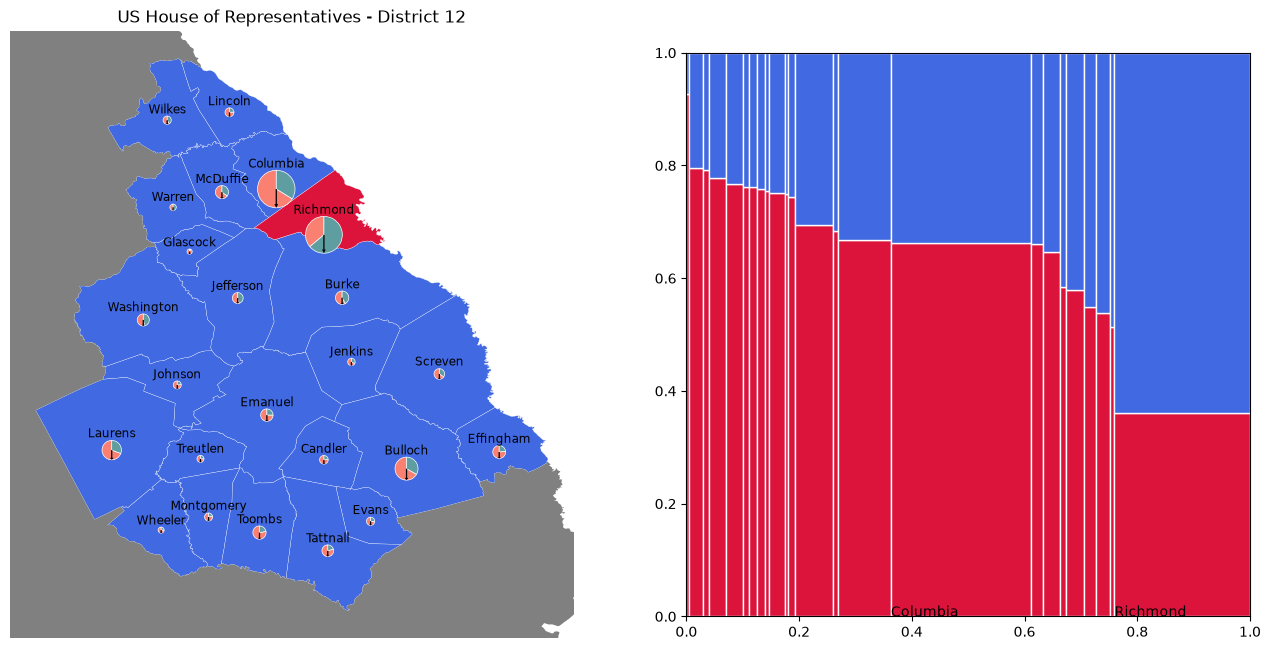

In [14]:
data0, ax = cd_map(12)
cd_marimekko(data0, ax)
plt.show()

# District 13

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


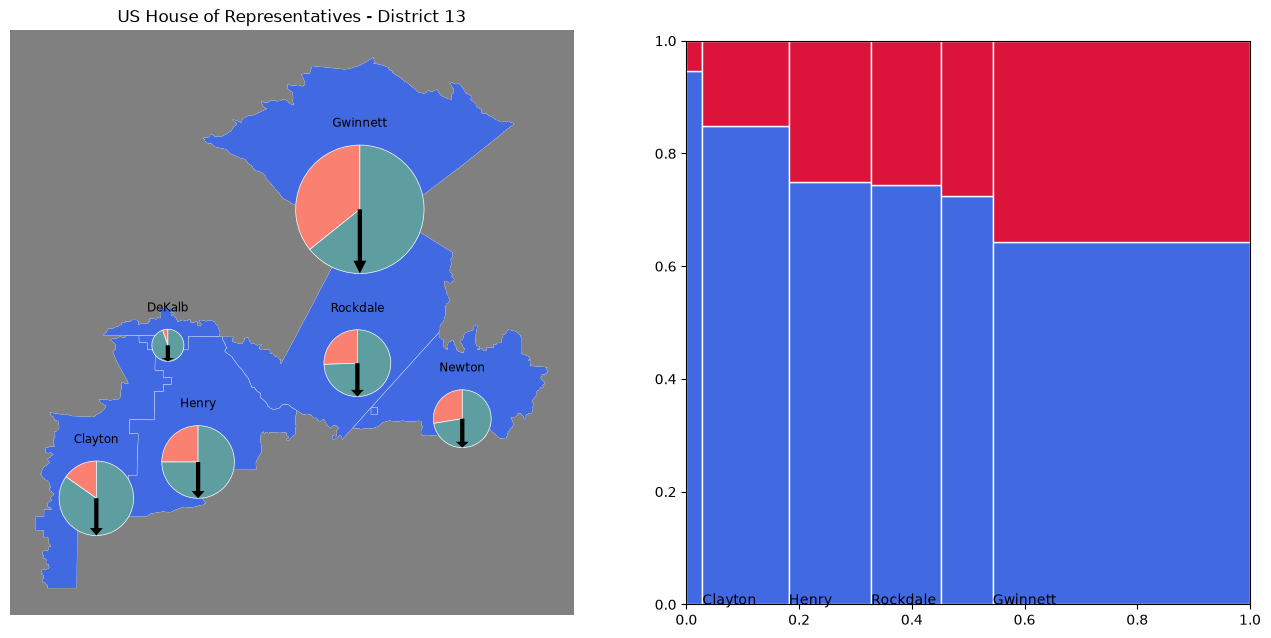

In [15]:
data0, ax = cd_map(13)
cd_marimekko(data0, ax)
plt.show()

# District 14

/tmp/ipykernel_554997/1565532646.py:72: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  x_coord_counties = district_counties.centroid.x
/tmp/ipykernel_554997/1565532646.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  y_coord_counties = district_counties.centroid.y


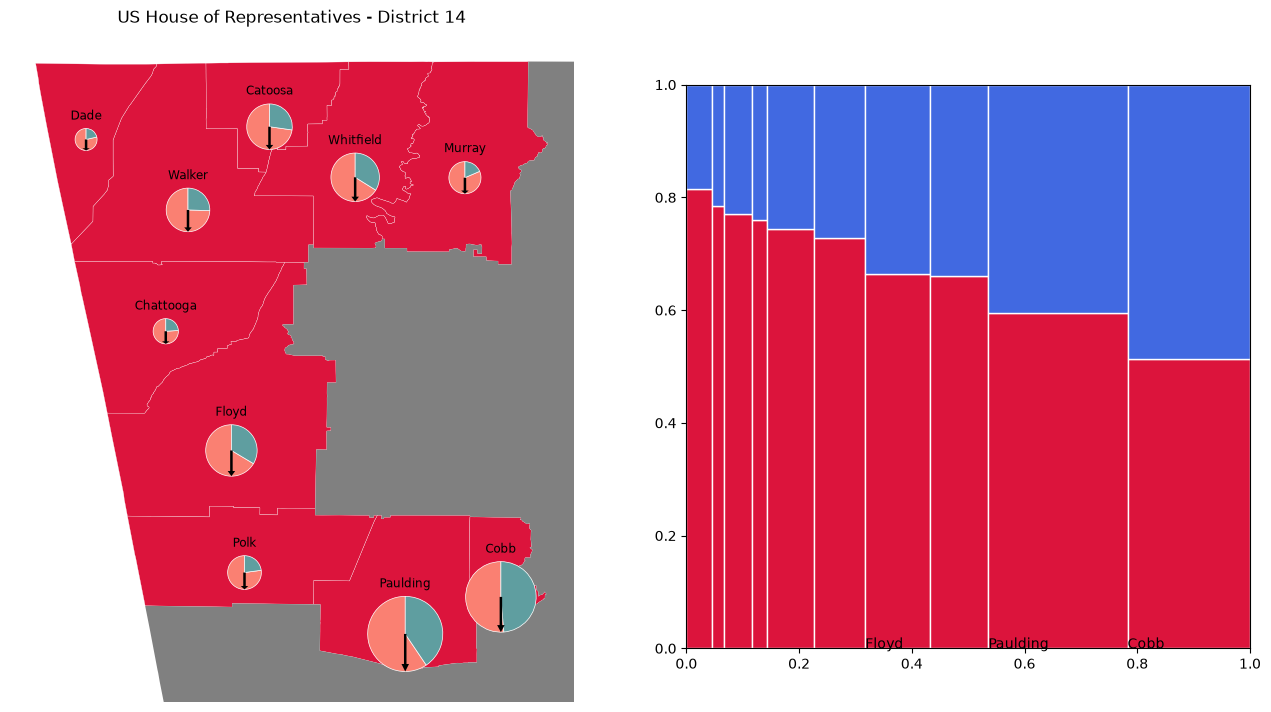

In [16]:
data0, ax = cd_map(14)
cd_marimekko(data0, ax)
plt.show()